# Predicting Insurance Claim Amounts
## Summary
Built a machine learning model to predict medical insurance charges using regression techniques. Applied data preprocessing, outlier removal, log transform and model tuning. Gradient Boosting with outlier removal gave the best performance.

### Importing important pandas libraries

In [316]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
data=pd.read_csv("insurance.csv")
# Basic data exploration
print("Shape of Dataset:")
print(data.shape)
print("\nColumn Names:")
print(data.columns)
print("\nFirst 5 Rows:")
print(data.head())


Shape of Dataset:
(1338, 7)

Column Names:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

First 5 Rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


### Handling missing values if exists

In [317]:
#checking missing values
data.isnull().sum().sort_values(ascending=False)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

There is no missing value

## Data Visualization

### BMI vs Charges

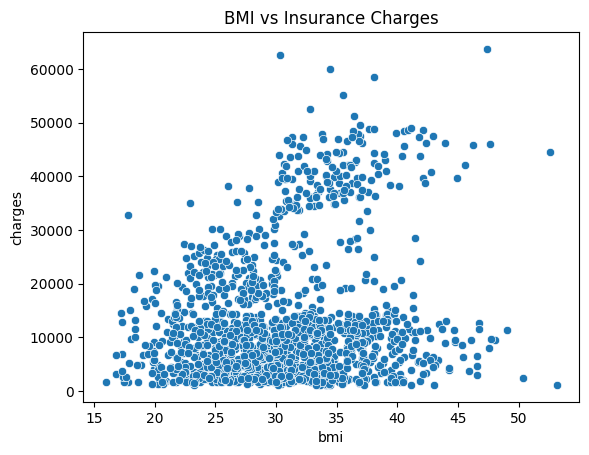

In [318]:
sns.scatterplot(x='bmi', y='charges', data=data)
plt.title("BMI vs Insurance Charges")
plt.show()

Higher BMI may increase medical risk, helps understand correlation

### Age vs Charges

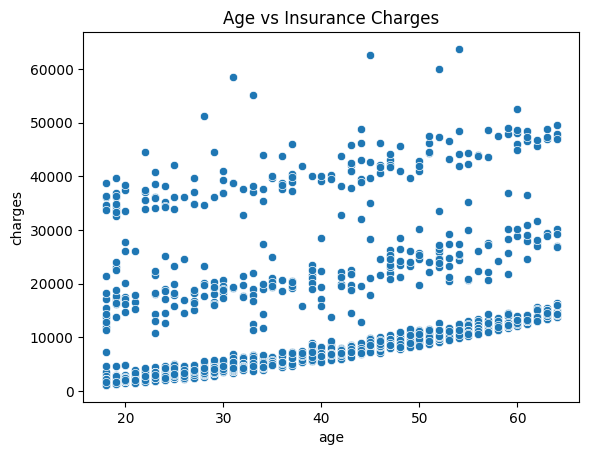

In [319]:
sns.scatterplot(x='age', y='charges', data=data)
plt.title("Age vs Insurance Charges")
plt.show()

Describes how insurance increases with age
and helps detect trend

### Smoking vs Charges

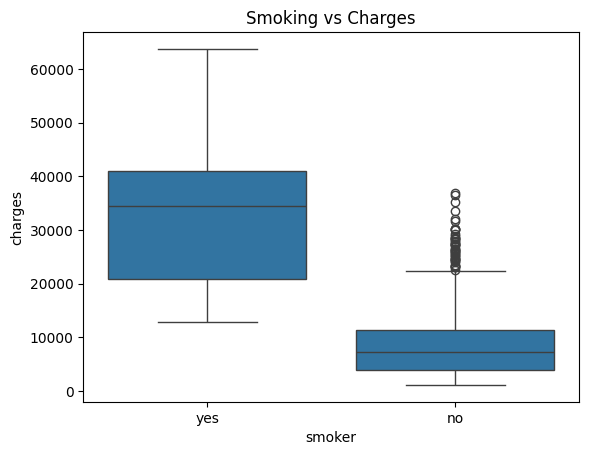

In [320]:
sns.boxplot(x='smoker', y='charges', data=data)
plt.title("Smoking vs Charges")
plt.show()

Smokers usually have higher charges.

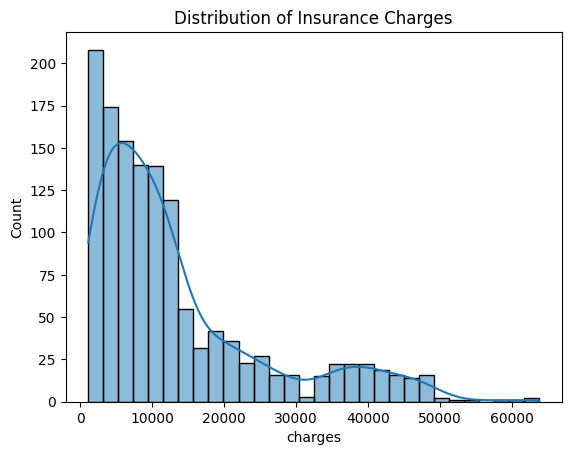

In [321]:
sns.histplot(data['charges'], kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

Feature Correlation
Correlation Heatmap

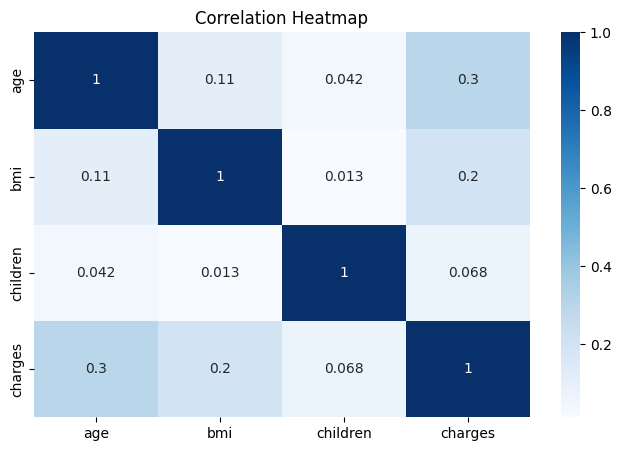

In [322]:
numeric_data = data.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))
sns.heatmap(numeric_data.corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

## Preprocessing

In [ ]:
#Encoding categorical columns
data = pd.get_dummies(data, drop_first=True)

# Baseline Model

### Training

In [324]:
X = data.drop('charges', axis=1)
y = data['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


### Evaluation

In [325]:
y_pred = gb.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2443.483262376879
RMSE: 4329.570010504765


# Data Preprocessing
## Removing outliers

From boxplot, histplot and feature correlation, it is observed that there are some outliers. to get better results, i will remove them first

Outlier Checking

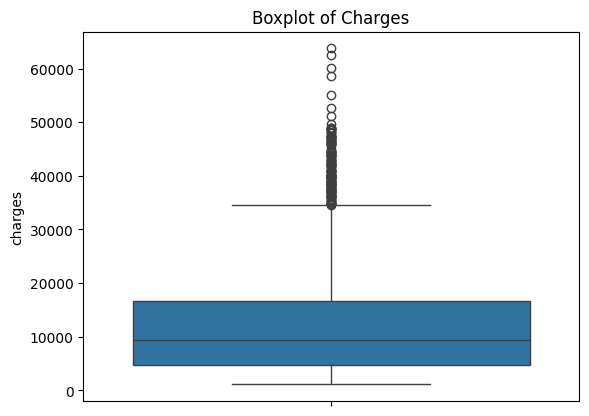

In [326]:
sns.boxplot(y=data['charges'])
plt.title("Boxplot of Charges")
plt.show()

“The boxplot of insurance charges shows the presence of several upper outliers, indicating some customers have exceptionally high medical expenses compared to the majority of policyholders.”

Removing outliers using quartile method

In [327]:
Q1 = data['charges'].quantile(0.25)
Q3 = data['charges'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['charges'] = data['charges'].clip(lower, upper)

Verification after capping

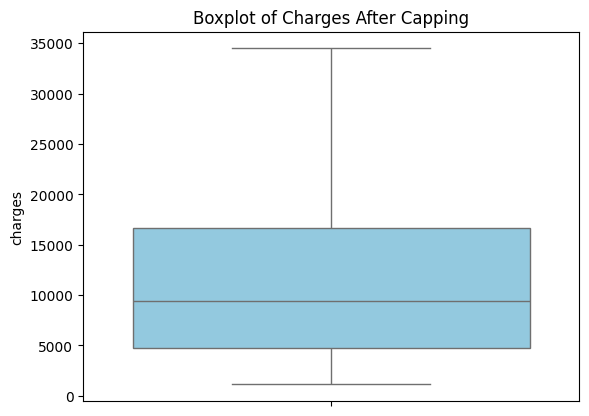

In [328]:
sns.boxplot(y=data['charges'], color='skyblue')
plt.title("Boxplot of Charges After Capping")
plt.show()

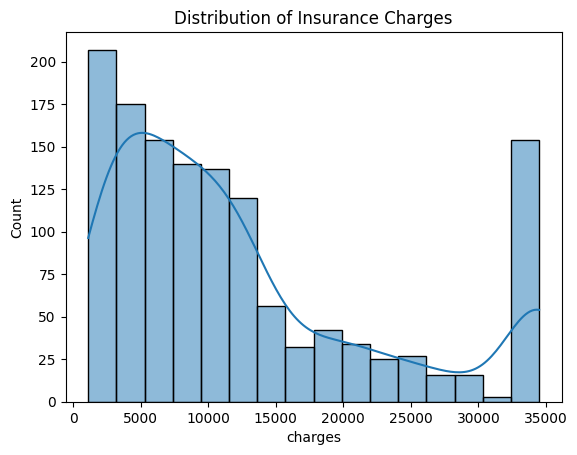

In [329]:
sns.histplot(data['charges'], kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

After applying IQR-based capping, no significant outliers are visible in the boxplot of insurance charges and in histplot it is showing that some outliers are removed. The extreme values are successfully limited within the acceptable range.

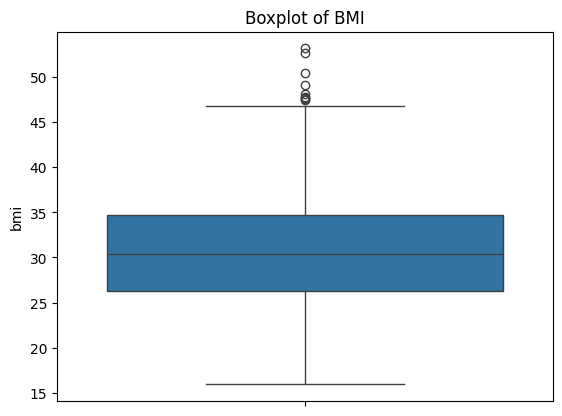

In [330]:
sns.boxplot(y=data['bmi'])
plt.title("Boxplot of BMI")
plt.show()

In [331]:
Q1 = data['bmi'].quantile(0.25)
Q3 = data['bmi'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data['bmi'] = data['bmi'].clip(lower, upper)

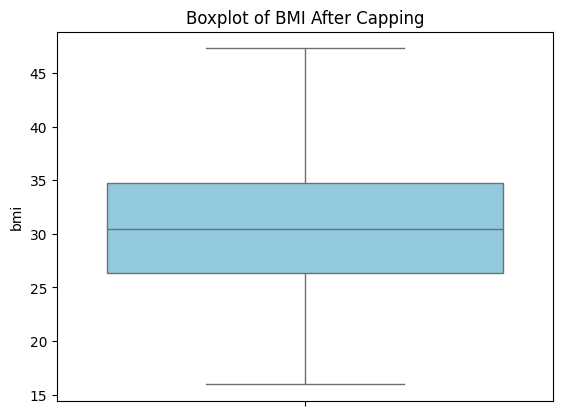

In [332]:
sns.boxplot(y=data['bmi'], color='skyblue')
plt.title("Boxplot of BMI After Capping")
plt.show()

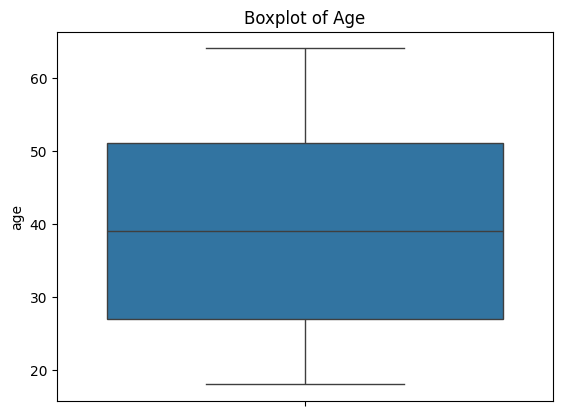

In [333]:
sns.boxplot(y=data['age'])
plt.title("Boxplot of Age")
plt.show()

“Outliers were identified in the charges and bmi features using boxplots and histplot. IQR-based capping was applied to limit extreme values while preserving all observations in the dataset. No significant outliers were observed in the age feature.”

### Dictionary
It is created to store the models evaluation performance using different methods

In [334]:
results = []

## Model after removing outlier

### Training

In [335]:
X = data.drop('charges', axis=1)
y = data['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.03, max_depth=3,random_state=42)
gb.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.03
,n_estimators,300
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


### Evaluation

In [336]:
y_pred = gb.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2158.944128888117
RMSE: 4044.062544174391


Appending the evaluated values in dictionary

In [337]:
results.append(["Outlier Removal", mae, rmse])

## Model with Log Transform

### Training

In [338]:
X = data.drop('charges', axis=1)
y = data['charges']
y = np.log1p(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


### Evaluation

In [339]:
y_pred_log = gb.predict(X_test)
y_test_original = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)
mae = mean_absolute_error(y_test_original, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1898.2309195070573
RMSE: 4175.988023049811


Appending the evaluated values in dictionary

In [340]:
results.append(["Log Transform", mae, rmse])

## Model with Gridsearchcv

In [341]:
X = data.drop('charges', axis=1)
y = data['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [342]:
param_grid = {
    "n_estimators": [200, 300],
    "learning_rate": [0.03, 0.05],
    "max_depth": [2, 3],
}
grid = GridSearchCV(estimator=gb, param_grid=param_grid, cv=5,
                     scoring="neg_mean_squared_error", n_jobs=-1)
grid.fit(X_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.03, 0.05], 'max_depth': [2, 3], 'n_estimators': [200, 300]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [343]:
y_pred = grid.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2435.6348158139203
RMSE: 4180.467868075964


Appending the evaluated values in dictionary

In [344]:
results.append(["GridSearchCV", mae, rmse])

In [345]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE"])
print(results_df)

             Model          MAE         RMSE
0  Outlier Removal  2158.944129  4044.062544
1    Log Transform  1898.230920  4175.988023
2     GridSearchCV  2435.634816  4180.467868


In [346]:
best = results_df.sort_values("RMSE").iloc[0]
print("Best Model:")
print(best)

Best Model:
Model    Outlier Removal
MAE          2158.944129
RMSE         4044.062544
Name: 0, dtype: object


## Conclusion
Outlier removal resulted in the best overall performance with the lowest RMSE (4044), making it the most effective approach for this dataset. Log transformation improved MAE but increased RMSE, while GridSearchCV did not provide significant improvement.